<a href="https://colab.research.google.com/github/scottspurlock/csc4422-s2026/blob/main/labs/day18_lab_spurlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMML Day 18 Lab: ANN

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier

In [ ]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1S0n9mD4uFujd-XCDrmBHIIQU1CobCqv8')
df.head()


,0,1,2,3,4,5,6,7,8,9,10
0,102.393791,-6.669607,4.139702,-506.777860,5001.020749,-1.073970,-2.550183,0.363348,1.787044,-0.070631,1.0
1,102.226595,-0.983775,5.996475,648.288942,4999.978850,0.988241,0.025666,1.318736,1.586718,-0.102418,0.0
2,101.035779,10.449141,10.245834,196.562477,4999.717040,-0.363915,-0.388911,-0.332252,1.693191,1.384075,1.0
3,97.059522,7.075832,8.621515,610.339461,4996.834356,-1.404712,0.341290,2.462631,0.011489,-0.229269,1.0
4,99.115294,-47.498000,9.093882,715.756109,4999.408722,2.058694,-1.583398,1.947976,-4.709636,0.579274,1.0


- Pull out the last column, 10, into a variable called y. This will be our target variable (class label).
- Make a variable called X to hold the first 10 columns (0 through 9).


In [ ]:
y = df['10']
X = df.drop('10', axis=1)


Divide the data into randomized training and test partitions. Use 20% of the data as the test set, keeping 80% for training.

In [ ]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=0)

ANN’s typically work better when data is scaled close to 0. Make sure to normalize or standardize.

In [ ]:
scaler = StandardScaler()

# Fit only to the training data
scaler.fit(Xtrain)

# Now apply the transformations to the data:
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)


Create a neural network model that has one hidden layer, with 4 nodes.

In [ ]:
model = MLPClassifier(hidden_layer_sizes=(4), # each number is the number of neurons in a layer
                      solver='adam',
                      learning_rate_init=0.01,
                      activation='relu',
                      batch_size=64,
                      max_iter=500,
                      early_stopping=True,
                      validation_fraction=0.1,
                      verbose=True)
# Fit the classifier to your training data.
model.fit(Xtrain, ytrain)

# Predict your test data.
ypred = model.predict(Xtest)

# Print out the classification report.
print(classification_report(ytest, ypred))


Iteration 1, loss = 0.61862752
Validation score: 0.715000
Iteration 2, loss = 0.55965769
Validation score: 0.752500
Iteration 3, loss = 0.54595844
Validation score: 0.742500
Iteration 4, loss = 0.53667367
Validation score: 0.757500
Iteration 5, loss = 0.53127943
Validation score: 0.750000
Iteration 6, loss = 0.52535670
Validation score: 0.762500
Iteration 7, loss = 0.51990627
Validation score: 0.760000
Iteration 8, loss = 0.51617735
Validation score: 0.765000
Iteration 9, loss = 0.51444521
Validation score: 0.772500
Iteration 10, loss = 0.51111521
Validation score: 0.777500
Iteration 11, loss = 0.51030944
Validation score: 0.775000
Iteration 12, loss = 0.50689401
Validation score: 0.782500
Iteration 13, loss = 0.50521827
Validation score: 0.785000
Iteration 14, loss = 0.50158562
Validation score: 0.772500
Iteration 15, loss = 0.49950987
Validation score: 0.775000
Iteration 16, loss = 0.49741799
Validation score: 0.787500
Iteration 17, loss = 0.49656845
Validation score: 0.785000
Iterat

## Check learning rates that are too low, good, and too high

In [ ]:
def get_loss_curve(Xtrain, ytrain, lr=0.01, hidden_layers = (4)):
    model = MLPClassifier(hidden_layer_sizes=hidden_layers,
                        solver='adam',
                        learning_rate_init=lr,
                        activation='relu',
                        batch_size=64,
                        max_iter=500,
                        early_stopping=True,
                        validation_fraction=0.1,
                        verbose=False)

    # Fit the classifier to your training data.
    model.fit(Xtrain, ytrain)
    return model.loss_curve_

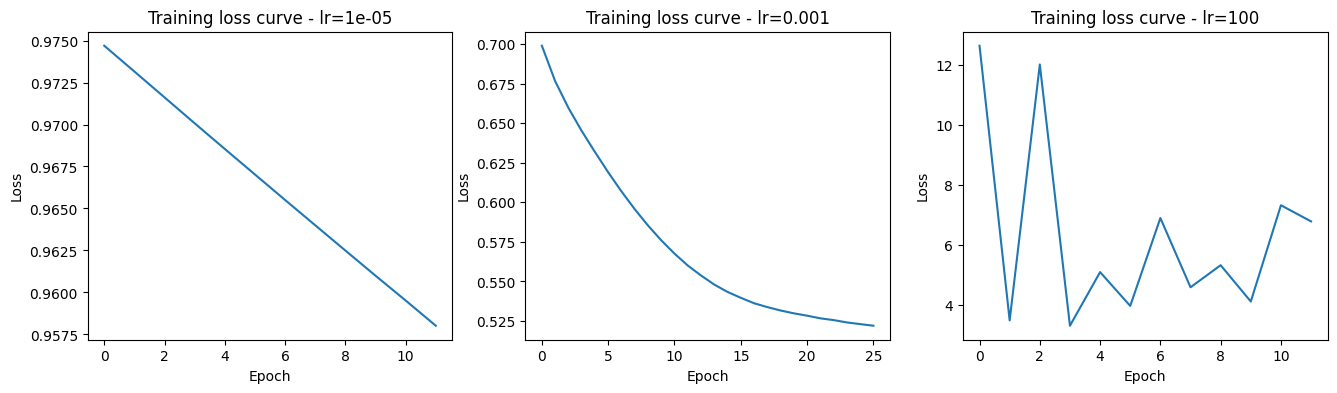

In [ ]:
loss_curves = []
learning_rates = [0.00001, 0.001, 100]
plt.figure(figsize=(16, 4))
for i, lr in enumerate(learning_rates):
    curve = get_loss_curve(Xtrain, ytrain, lr)
    plt.subplot(1, 3, i+1)
    plt.plot(curve)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.title(f'Training loss curve - lr={lr}')
plt.show()


## Find the best hyperparams

In [ ]:
model = MLPClassifier(hidden_layer_sizes=(64, 128, 64), # each number is the number of neurons in a layer
                      solver='adam',
                      learning_rate_init=0.01,
                      activation='relu',
                      batch_size=64,
                      max_iter=500,
                      early_stopping=True,
                      validation_fraction=0.1,
                      verbose=True)

In [ ]:
# Fit the classifier to your training data.
model.fit(Xtrain, ytrain)

# Predict your test data.
ypred = model.predict(Xtest)

# Print out the classification report.
print(classification_report(ytest, ypred))


Iteration 1, loss = 0.50687237
Validation score: 0.785000
Iteration 2, loss = 0.42567896
Validation score: 0.825000
Iteration 3, loss = 0.37639804
Validation score: 0.855000
Iteration 4, loss = 0.34964562
Validation score: 0.865000
Iteration 5, loss = 0.32377847
Validation score: 0.862500
Iteration 6, loss = 0.32967247
Validation score: 0.857500
Iteration 7, loss = 0.31023802
Validation score: 0.855000
Iteration 8, loss = 0.29008613
Validation score: 0.865000
Iteration 9, loss = 0.29601600
Validation score: 0.875000
Iteration 10, loss = 0.28570012
Validation score: 0.870000
Iteration 11, loss = 0.26733626
Validation score: 0.867500
Iteration 12, loss = 0.27011491
Validation score: 0.862500
Iteration 13, loss = 0.25302184
Validation score: 0.862500
Iteration 14, loss = 0.24543945
Validation score: 0.867500
Iteration 15, loss = 0.23401835
Validation score: 0.850000
Iteration 16, loss = 0.23498329
Validation score: 0.855000
Iteration 17, loss = 0.23248654
Validation score: 0.870000
Iterat

In [ ]:
# check training data - overfitting?
ypred = model.predict(Xtrain)
print(classification_report(ytrain, ypred))

              precision    recall  f1-score   support

         0.0       0.91      0.89      0.90      1994
         1.0       0.89      0.91      0.90      2006

    accuracy                           0.90      4000
   macro avg       0.90      0.90      0.90      4000
weighted avg       0.90      0.90      0.90      4000

